# ROUND 3 — back-to-basics EDA

Goal: forget options theory for now. Just look at the raw data.

1. **Section 1 — products.** What do the two spot products (`HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`) actually look like? Price, volume, spread, depth — the same basics we'd run on any new product.
2. **Section 2 — vouchers vs the underlying.** Now bring in the 10 `VEV_*` vouchers and compare them to `VELVETFRUIT_EXTRACT`. Just price relationships — no Black-Scholes, no IV, no greeks yet.

Data: `3/ROUND_3/prices_round_3_day_{0,1,2}.csv` and `trades_round_3_day_{0,1,2}.csv`.

## 0. Setup

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("3/ROUND_3")

SPOT = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VOUCHERS = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500",
]
VOUCHER_K = {v: int(v.split("_")[1]) for v in VOUCHERS}
ALL_PRODUCTS = SPOT + VOUCHERS
UNDERLYING = "VELVETFRUIT_EXTRACT"

In [22]:
def load_prices(folder: Path) -> pd.DataFrame:
    frames = [pd.read_csv(p, sep=";") for p in sorted(folder.glob("prices_round_3_day_*.csv"))]
    df = pd.concat(frames, ignore_index=True)
    df["t"] = (df["day"] - df["day"].min()) * 1_000_000 + df["timestamp"]
    return df

def load_trades(folder: Path, days: list[int]) -> pd.DataFrame:
    frames = []
    for d in days:
        p = folder / f"trades_round_3_day_{d}.csv"
        if p.exists():
            f = pd.read_csv(p, sep=";")
            f["day"] = d
            frames.append(f)
    df = pd.concat(frames, ignore_index=True)
    df["t"] = (df["day"] - df["day"].min()) * 1_000_000 + df["timestamp"]
    return df

prices = load_prices(DATA_DIR)
days = sorted(prices["day"].unique().tolist())
trades = load_trades(DATA_DIR, days)

print("days:", days)
print("prices rows:", len(prices), "| trades rows:", len(trades))
print("products in prices:", sorted(prices["product"].unique()))

# Day boundaries on the merged timeline (for vertical lines on plots).
day_bounds = [(d - days[0]) * 1_000_000 for d in days[1:]]

days: [0, 1, 2]
prices rows: 360000 | trades rows: 4048
products in prices: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [23]:
# Helper: pivot to a wide mid-price frame.
def pivot_mid(df: pd.DataFrame, products: list[str]) -> pd.DataFrame:
    sub = df[df["product"].isin(products)]
    out = sub.pivot_table(index="t", columns="product", values="mid_price", aggfunc="last")
    return out.reindex(columns=products)

mids = pivot_mid(prices, ALL_PRODUCTS)
print("mids shape:", mids.shape)
mids.head()

mids shape: (30000, 12)


product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
t,,,,,,,,,,,,
0,10000.0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
100,10000.0,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
200,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
300,10002.0,5250.5,1250.5,750.0,257.5,172.0,102.5,53.0,23.5,8.5,0.5,0.5
400,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5


## 1. The two spot products

`HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` are the only two non-derivative products this round. Treat them like Round 1: price level, returns, spread, depth, traded volume.

### 1.1 Price summary

In [24]:
rows = []
for p in SPOT:
    sub = prices[prices["product"] == p]
    mid = sub["mid_price"].dropna()
    spr = (sub["ask_price_1"] - sub["bid_price_1"]).dropna()
    depth = (sub["bid_volume_1"].fillna(0) + sub["ask_volume_1"].fillna(0))
    rows.append({
        "product": p,
        "n_snapshots": len(sub),
        "mid_min": mid.min(),
        "mid_max": mid.max(),
        "mid_mean": round(mid.mean(), 2),
        "mid_std": round(mid.std(), 2),
        "spread_mean": round(spr.mean(), 2),
        "spread_median": spr.median(),
        "top_depth_mean": round(depth.mean(), 1),
    })
pd.DataFrame(rows).set_index("product")

,n_snapshots,mid_min,mid_max,mid_mean,mid_std,spread_mean,spread_median,top_depth_mean
product,,,,,,,,
HYDROGEL_PACK,30000,9891.0,10079.0,9990.81,31.94,15.72,16.0,24.8
VELVETFRUIT_EXTRACT,30000,5198.0,5300.0,5250.10,15.63,4.99,5.0,75.6


### 1.2 Mid-price time series — separate axes

Different price levels (HYDROGEL ~ tens of thousands? VEV ~ thousands), so plot them on their own panels first.

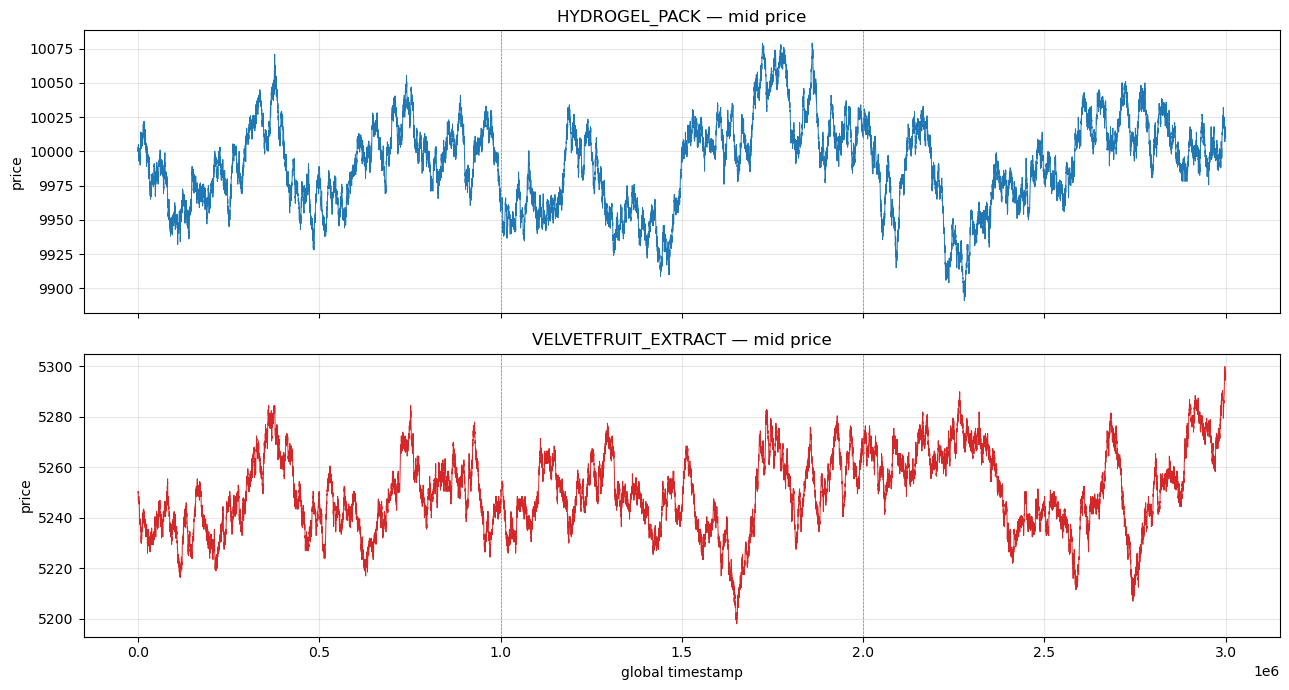

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, p, color in zip(axes, SPOT, ["#1f77b4", "#d62728"]):
    ax.plot(mids.index, mids[p], color=color, lw=0.7)
    for b in day_bounds:
        ax.axvline(b, color="#888", lw=0.5, ls="--")
    ax.set_title(f"{p} — mid price")
    ax.set_ylabel("price")
axes[-1].set_xlabel("global timestamp")
plt.tight_layout()
plt.show()

### 1.3 Returns distribution

Log returns in basis points. Looking for: thick tails, jumps, asymmetry.

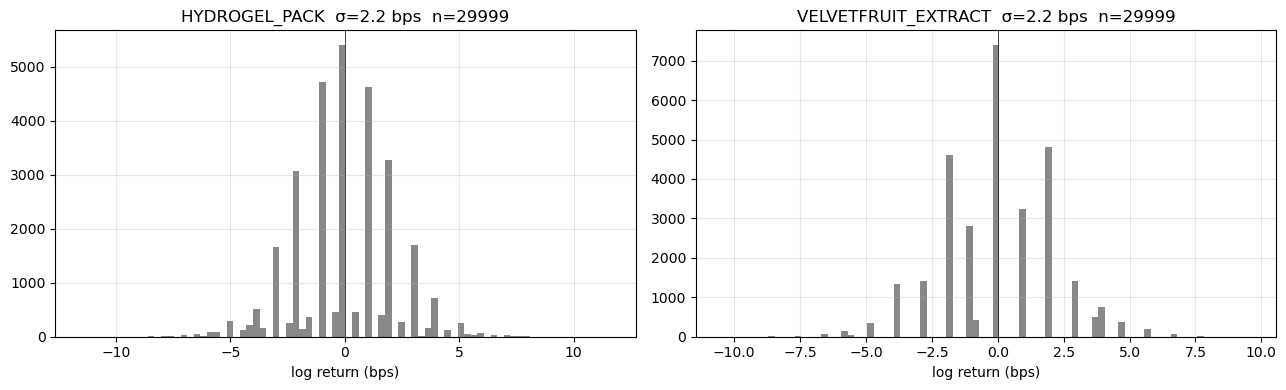

In [26]:
rets = np.log(mids[SPOT].where(mids[SPOT] > 0)).diff() * 1e4

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, p in zip(axes, SPOT):
    x = rets[p].dropna().values
    ax.hist(x, bins=80, color="#888", edgecolor="none")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{p}  σ={x.std():.1f} bps  n={len(x)}")
    ax.set_xlabel("log return (bps)")
plt.tight_layout()
plt.show()

### 1.4 Spread + top-of-book depth

How wide is the book and how much sits at level 1? This sets a hard limit on edge before fees.

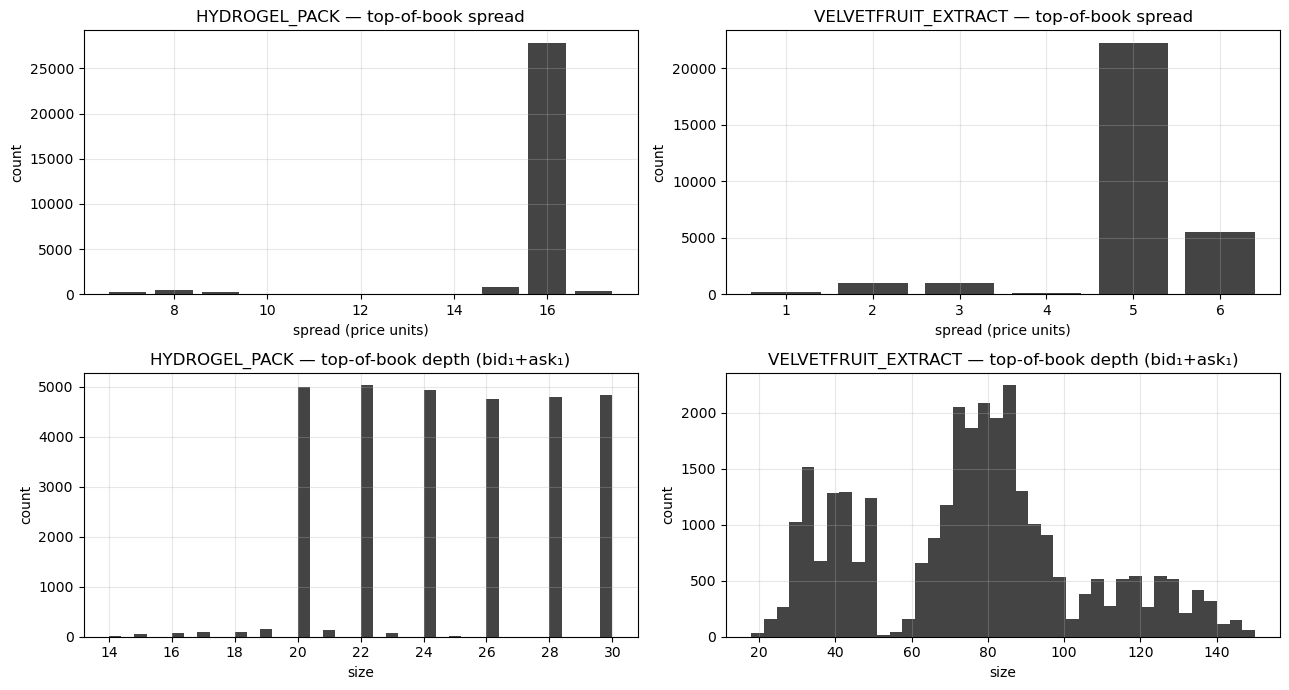

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, p in enumerate(SPOT):
    sub = prices[prices["product"] == p]
    spr = (sub["ask_price_1"] - sub["bid_price_1"]).dropna()
    depth = sub["bid_volume_1"].fillna(0) + sub["ask_volume_1"].fillna(0)

    ax = axes[0, col]
    vc = spr.value_counts().sort_index()
    ax.bar(vc.index, vc.values, color="#444")
    ax.set_title(f"{p} — top-of-book spread")
    ax.set_xlabel("spread (price units)")
    ax.set_ylabel("count")

    ax = axes[1, col]
    ax.hist(depth, bins=40, color="#444")
    ax.set_title(f"{p} — top-of-book depth (bid₁+ask₁)")
    ax.set_xlabel("size")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

### 1.5 Traded volume

From `trades_*.csv`. Aggressor flow / quote-side analysis is later — for now just "how much actually trades".

symbol  HYDROGEL_PACK  VELVETFRUIT_EXTRACT
day                                       
0                1349                 2689
1                1485                 2685
2                1244                 2895


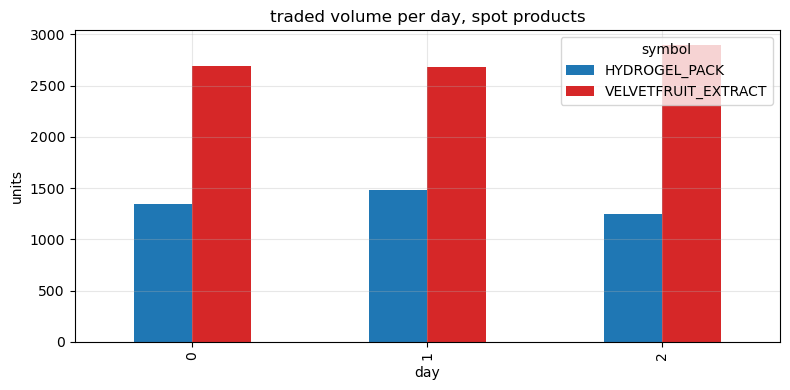

In [28]:
vol = (
    trades[trades["symbol"].isin(SPOT)]
    .groupby(["day", "symbol"])["quantity"].sum()
    .unstack(fill_value=0)
)
print(vol)

fig, ax = plt.subplots(figsize=(8, 4))
vol.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
ax.set_title("traded volume per day, spot products")
ax.set_ylabel("units")
ax.set_xlabel("day")
plt.tight_layout()
plt.show()

### 1.6 HYDROGEL_PACK -- EMA deviation (mean-reversion candidate)

The §1.2 HYDROGEL panel oscillates 9900-10080 around ~10000 with visible cycles -- looks like Round-1 SQUID_INK material. The simplest mean-reversion model: track a fast EMA, trade the deviation `dev_t = mid_t - EMA_t` against fixed thresholds (the 2024 winners did exactly this on Volcanic Rock).

Plot top: mid + EMA. Plot bottom: deviation with +/- 1sigma and +/- 2sigma bands. ACF1 of `dev_t` shown in title -- positive = the deviation is persistent (good, you can scalp it). 1-lag autocorr of `Δ(dev_t)` shown too -- negative = the deviation mean-reverts at a tick scale.

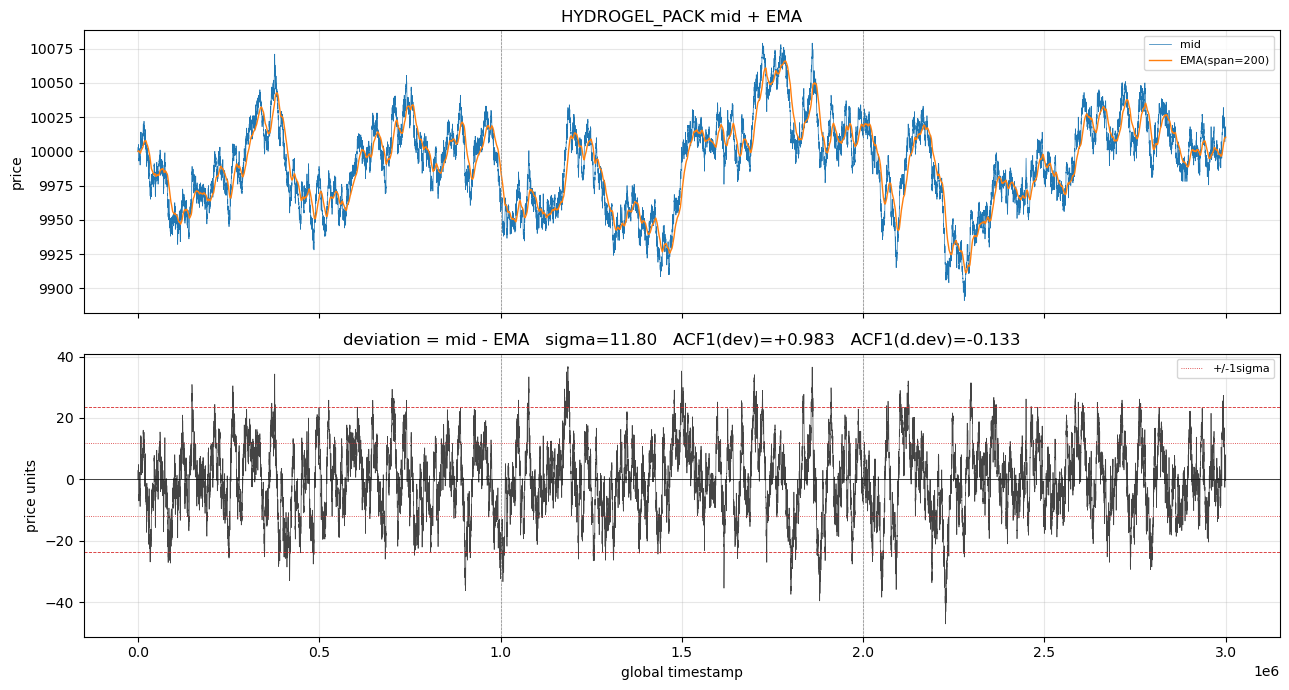

|dev| >= 1sigma: 32.2% of ticks (9661 ticks)
|dev| >= 2sigma: 4.4% of ticks (1317 ticks)


In [29]:
HYDRO = "HYDROGEL_PACK"
mid_h = mids[HYDRO].dropna()
EMA_SPAN = 200   # tune later

ema = mid_h.ewm(span=EMA_SPAN, adjust=False).mean()
dev = mid_h - ema
dev_sigma = dev.std()

acf1_dev = dev.autocorr(lag=1)
acf1_ddev = dev.diff().dropna().autocorr(lag=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax = axes[0]
ax.plot(mid_h.index, mid_h.values, color="#1f77b4", lw=0.5, label="mid")
ax.plot(mid_h.index, ema.values, color="#ff7f0e", lw=1.0, label=f"EMA(span={EMA_SPAN})")
for tb in day_bounds:
    ax.axvline(tb, color="#888", lw=0.5, ls="--")
ax.set_title(f"{HYDRO} mid + EMA")
ax.set_ylabel("price")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(dev.index, dev.values, color="#444", lw=0.5)
ax.axhline(0, color="black", lw=0.5)
for k, ls in [(1, ":"), (2, "--")]:
    ax.axhline(+k * dev_sigma, color="#d62728", lw=0.6, ls=ls, label=f"+/-{k}sigma" if k == 1 else None)
    ax.axhline(-k * dev_sigma, color="#d62728", lw=0.6, ls=ls)
for tb in day_bounds:
    ax.axvline(tb, color="#888", lw=0.5, ls="--")
ax.set_title(f"deviation = mid - EMA   sigma={dev_sigma:.2f}   ACF1(dev)={acf1_dev:+.3f}   ACF1(d.dev)={acf1_ddev:+.3f}")
ax.set_ylabel("price units")
ax.set_xlabel("global timestamp")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# How often does dev exceed +/-1sigma, +/-2sigma? (rough trade-frequency proxy)
for k in (1, 2):
    pct = (dev.abs() >= k * dev_sigma).mean() * 100
    print(f"|dev| >= {k}sigma: {pct:.1f}% of ticks ({int(pct/100*len(dev))} ticks)")


## 2. Vouchers vs the underlying

Now the 10 `VEV_*` vouchers. Each is a call on `VELVETFRUIT_EXTRACT` with a strike encoded in the name. We are *not* doing IV / Black-Scholes here. Just:

- what the voucher prices look like over time
- a snapshot of price-vs-strike (the call curve)
- voucher mid vs intrinsic value `max(S − K, 0)`
- how voucher mid moves when VEV moves

If something clearly mispriced jumps out at this level, no theory is needed.

### 2.1 Voucher mid prices, all on one plot

Symlog y-axis because the deep-OTM vouchers sit near 0 while the deep-ITM ones are in the hundreds.

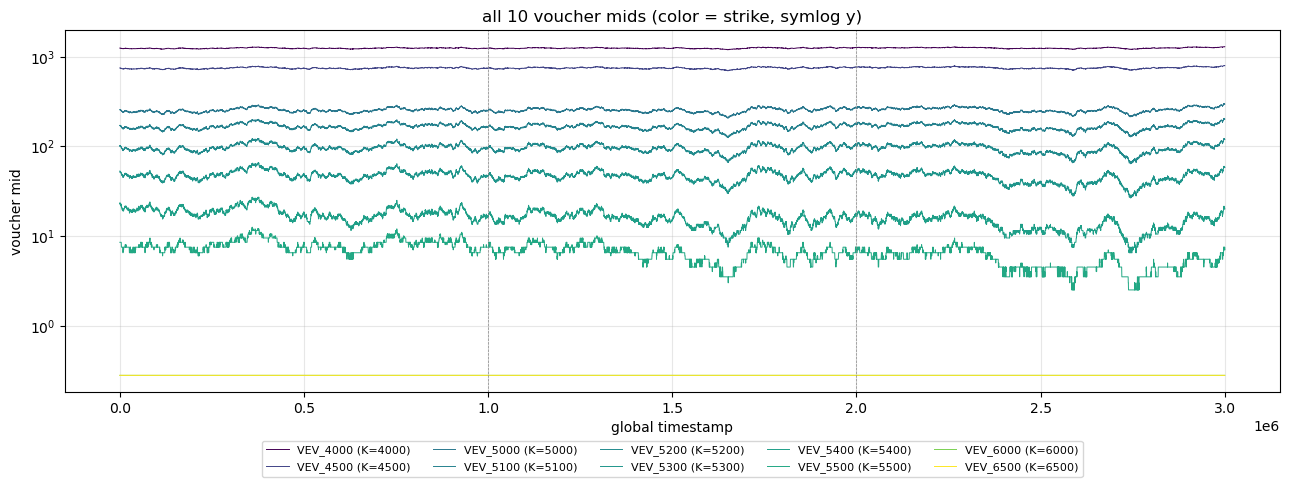

In [30]:
from matplotlib import cm
ks = np.array([VOUCHER_K[v] for v in VOUCHERS], dtype=float)
norm = (ks - ks.min()) / (ks.max() - ks.min())
VCOL = {v: cm.viridis(n) for v, n in zip(VOUCHERS, norm)}

fig, ax = plt.subplots(figsize=(13, 5))
for v in VOUCHERS:
    ax.plot(mids.index, mids[v], color=VCOL[v], lw=0.7, label=f"{v} (K={VOUCHER_K[v]})")
ax.set_yscale("symlog", linthresh=1.0)
for b in day_bounds:
    ax.axvline(b, color="#888", lw=0.5, ls="--")
ax.set_title("all 10 voucher mids (color = strike, symlog y)")
ax.set_ylabel("voucher mid")
ax.set_xlabel("global timestamp")
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

### 2.2 Voucher mid vs strike — call-curve snapshots

Three timestamps per day. A call's price must (a) be ≥ 0, (b) be ≥ intrinsic `max(S−K, 0)`, and (c) be a monotone-decreasing, convex function of strike. Anything that violates this without a tick-discreteness excuse is free money.

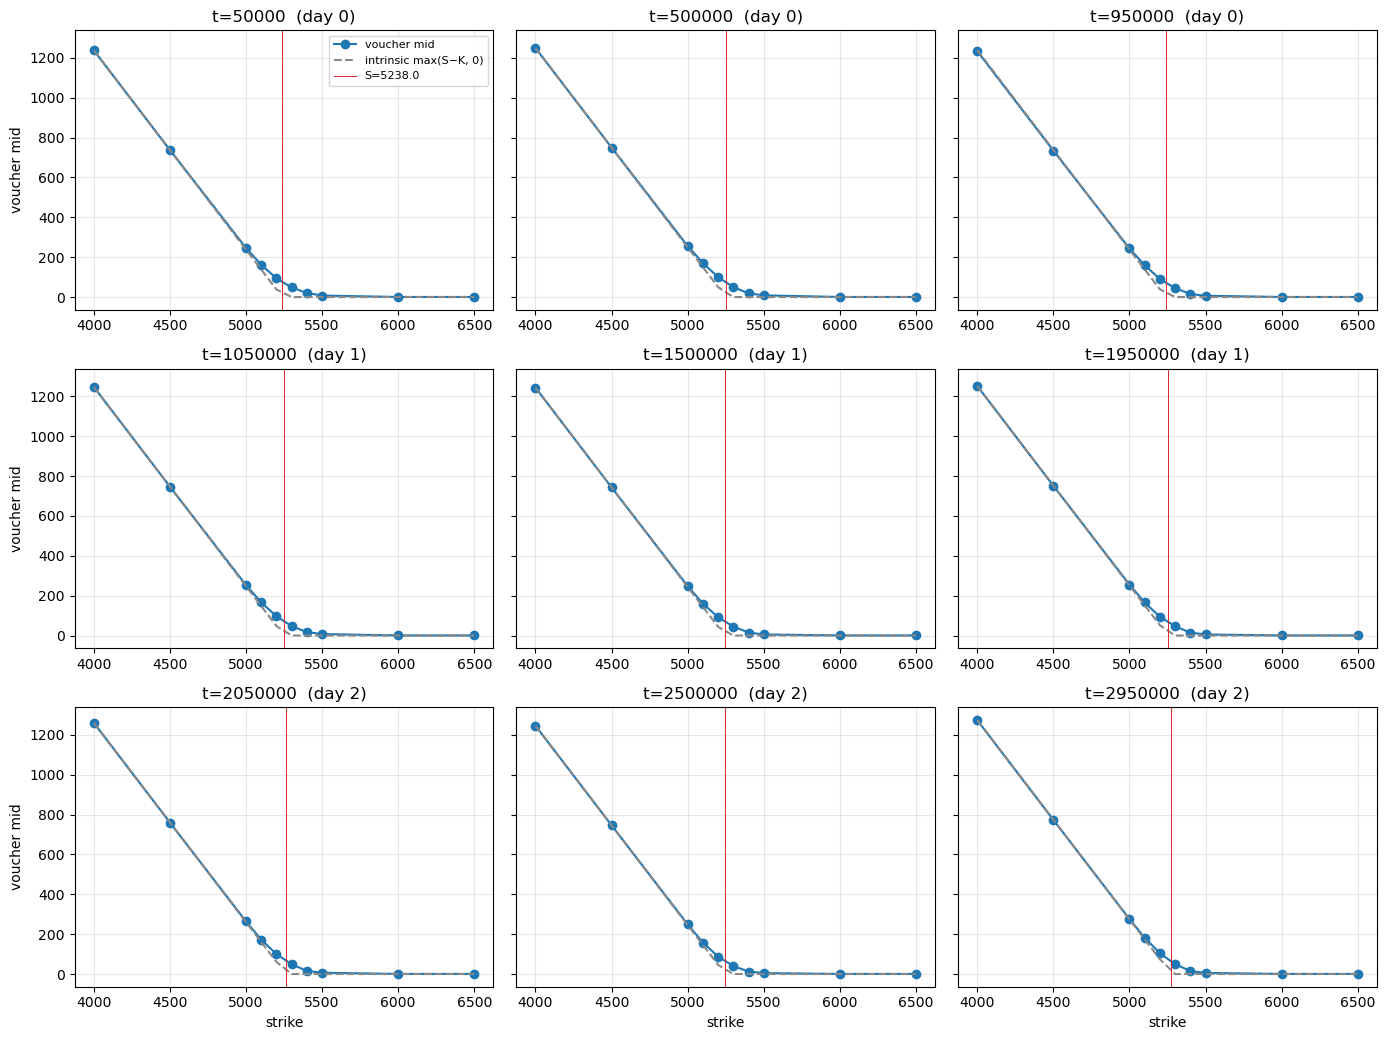

In [31]:
snap_ts = []
for d in days:
    d_off = (d - days[0]) * 1_000_000
    for frac in (0.05, 0.5, 0.95):
        snap_ts.append(int(d_off + frac * 1_000_000))

fig, axes = plt.subplots(len(days), 3, figsize=(14, 3.5 * len(days)), sharey=True)
axes = np.atleast_2d(axes)
ks_sorted = sorted(VOUCHERS, key=lambda v: VOUCHER_K[v])
K_arr = np.array([VOUCHER_K[v] for v in ks_sorted])

for i, t in enumerate(snap_ts):
    r, c = i // 3, i % 3
    ax = axes[r, c]
    nearest = mids.index.get_indexer([t], method="nearest")[0]
    row = mids.iloc[nearest]
    S = row[UNDERLYING]
    voucher_mid = np.array([row[v] for v in ks_sorted])
    intrinsic = np.maximum(S - K_arr, 0)

    ax.plot(K_arr, voucher_mid, "o-", color="#1f77b4", label="voucher mid")
    ax.plot(K_arr, intrinsic, "--", color="#888", label="intrinsic max(S−K, 0)")
    ax.axvline(S, color="#d62728", lw=0.7, label=f"S={S:.1f}")
    ax.set_title(f"t={t}  (day {row.name // 1_000_000 + days[0]})")
    if c == 0:
        ax.set_ylabel("voucher mid")
    if r == len(days) - 1:
        ax.set_xlabel("strike")
    if i == 0:
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Voucher mid vs intrinsic, over time

For each voucher, plot `mid_t` and `max(S_t − K, 0)` on the same axes. The gap is **time value**. Deep-ITM vouchers should track intrinsic almost perfectly; ATM vouchers should sit clearly above; deep-OTM should be near zero throughout.

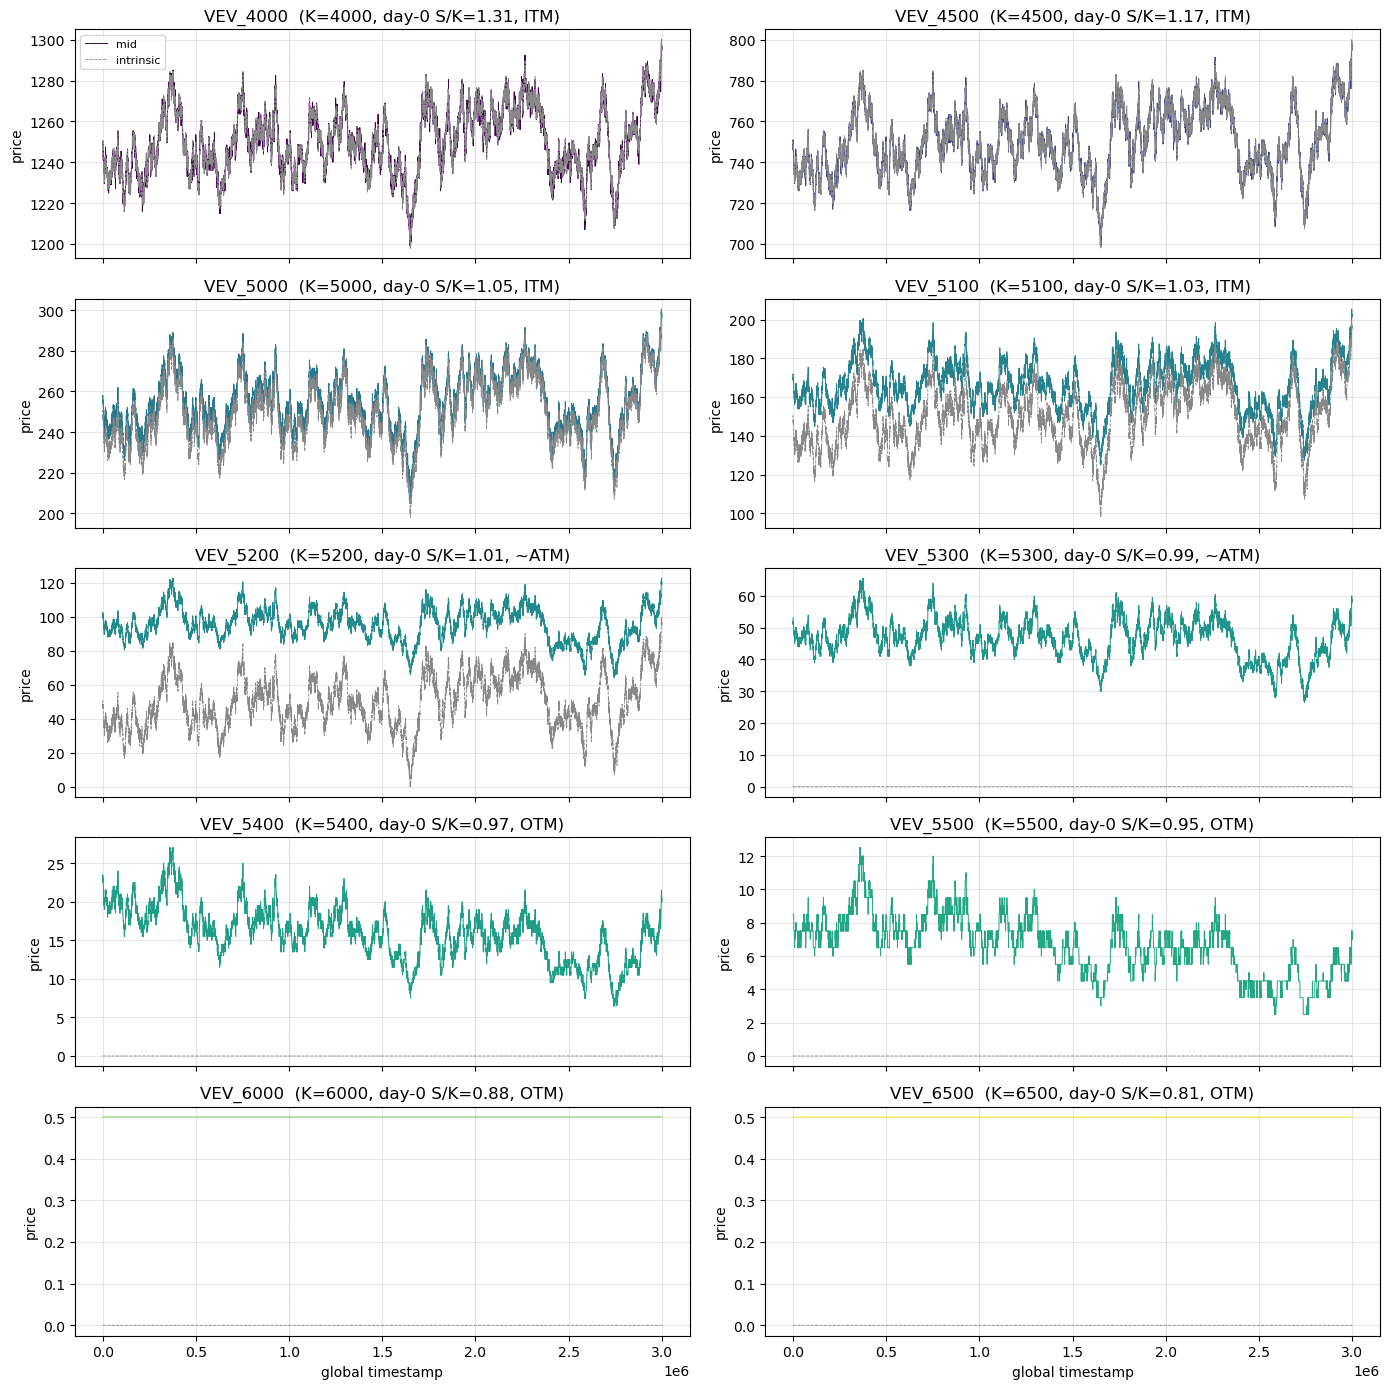

In [32]:
S = mids[UNDERLYING]
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
for i, v in enumerate(sorted(VOUCHERS, key=lambda x: VOUCHER_K[x])):
    ax = axes[i // 2, i % 2]
    K = VOUCHER_K[v]
    intr = (S - K).clip(lower=0)
    ax.plot(mids.index, mids[v], color=VCOL[v], lw=0.7, label="mid")
    ax.plot(mids.index, intr, color="#888", lw=0.6, ls="--", label="intrinsic")
    for b in day_bounds:
        ax.axvline(b, color="#bbb", lw=0.4, ls=":")
    moneyness = S.iloc[0] / K
    tag = "ITM" if moneyness > 1.02 else ("OTM" if moneyness < 0.98 else "~ATM")
    ax.set_title(f"{v}  (K={K}, day-0 S/K={moneyness:.2f}, {tag})")
    ax.set_ylabel("price")
    if i == 0:
        ax.legend(fontsize=8)
axes[-1, 0].set_xlabel("global timestamp")
axes[-1, 1].set_xlabel("global timestamp")
plt.tight_layout()
plt.show()

### 2.4 Voucher mid vs VEV mid — scatter

For each voucher, x = `S_t`, y = `mid_t`. Color = global timestamp (so you can see if the relationship drifts across days, which on options is expected — time decay shifts the whole curve down).

What to look for: a clean, monotone curve. ITM vouchers should look almost linear with slope ≈ 1; ATM should look like the bottom of a hockey stick; OTM should hug zero with a slight upturn at the right edge.

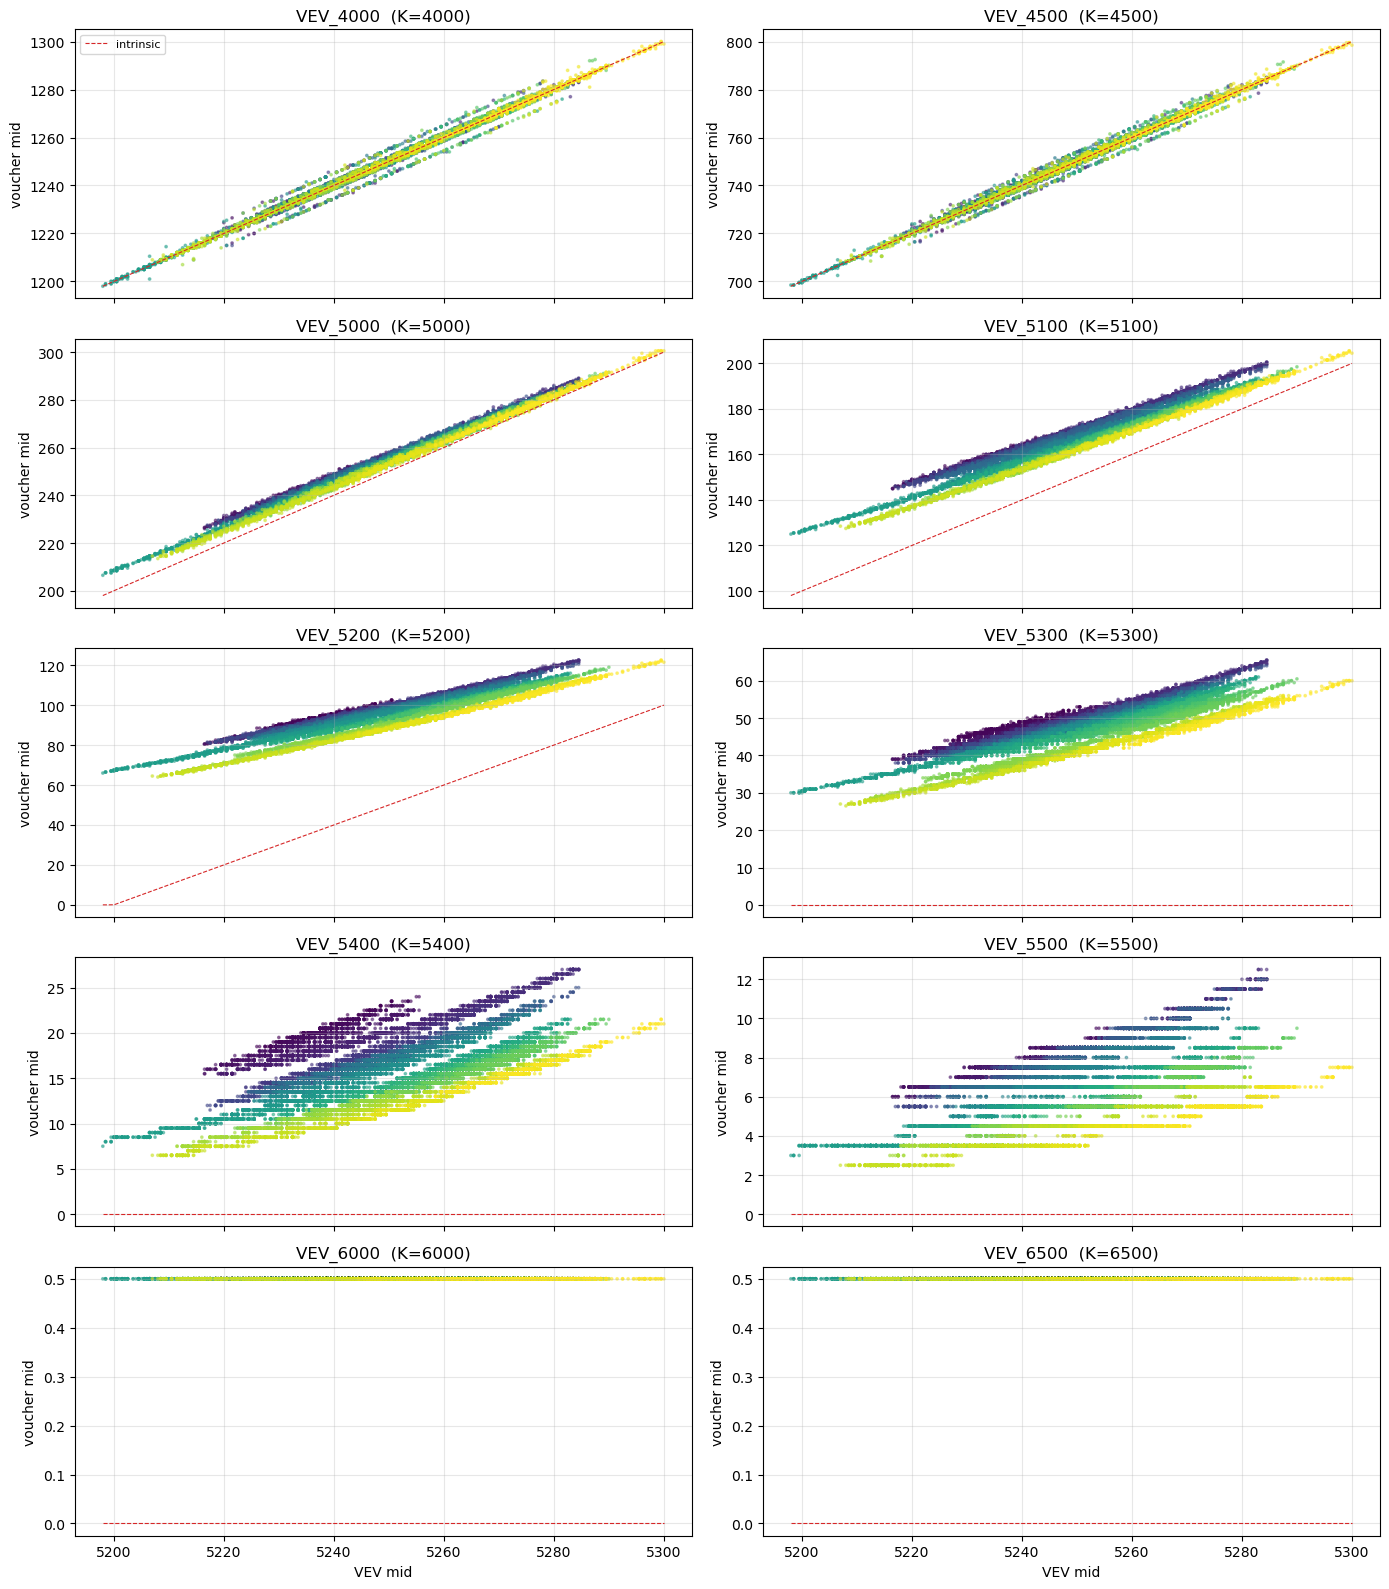

In [33]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
t_arr = mids.index.to_numpy()
for i, v in enumerate(sorted(VOUCHERS, key=lambda x: VOUCHER_K[x])):
    ax = axes[i // 2, i % 2]
    K = VOUCHER_K[v]
    mask = mids[v].notna() & mids[UNDERLYING].notna()
    sc = ax.scatter(
        mids.loc[mask, UNDERLYING], mids.loc[mask, v],
        c=t_arr[mask], cmap="viridis", s=3, alpha=0.5,
    )
    # Intrinsic line for reference.
    s_lin = np.linspace(mids[UNDERLYING].min(), mids[UNDERLYING].max(), 100)
    ax.plot(s_lin, np.maximum(s_lin - K, 0), color="#d62728", lw=0.8, ls="--", label="intrinsic")
    ax.set_title(f"{v}  (K={K})")
    ax.set_ylabel("voucher mid")
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")
axes[-1, 0].set_xlabel("VEV mid")
axes[-1, 1].set_xlabel("VEV mid")
plt.tight_layout()
plt.show()

### 2.5 Return correlation: each voucher vs VEV

Simple Pearson correlation of one-tick log returns. Deep-ITM vouchers should approach 1 (they *are* the underlying ± a constant). Deep-OTM should be lower because the price barely moves on most VEV ticks.

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


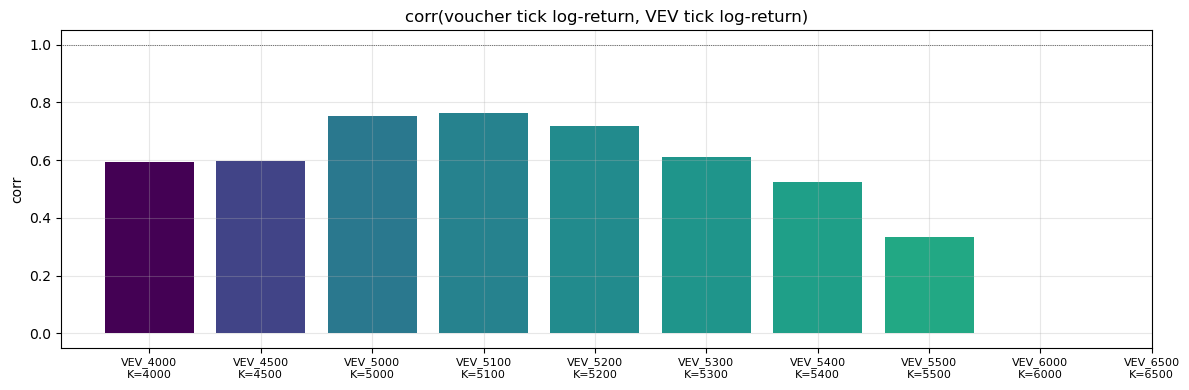

VEV_4000    0.595
VEV_4500    0.598
VEV_5000    0.752
VEV_5100    0.763
VEV_5200    0.719
VEV_5300    0.612
VEV_5400    0.525
VEV_5500    0.334
VEV_6000      NaN
VEV_6500      NaN
dtype: float64

In [34]:
all_rets = np.log(mids.where(mids > 0)).diff()
corr_to_vev = pd.Series(
    {v: all_rets[v].corr(all_rets[UNDERLYING]) for v in VOUCHERS}
).reindex(sorted(VOUCHERS, key=lambda x: VOUCHER_K[x]))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    range(len(corr_to_vev)), corr_to_vev.values,
    color=[VCOL[v] for v in corr_to_vev.index],
)
ax.set_xticks(range(len(corr_to_vev)))
ax.set_xticklabels([f"{v}\nK={VOUCHER_K[v]}" for v in corr_to_vev.index], rotation=0, fontsize=8)
ax.set_ylim(-0.05, 1.05)
ax.axhline(1, color="k", lw=0.5, ls=":")
ax.set_title("corr(voucher tick log-return, VEV tick log-return)")
ax.set_ylabel("corr")
plt.tight_layout()
plt.show()

corr_to_vev.round(3)

### 2.6 Per-day traded volume by voucher

Which strikes are actually liquid? This decides what we can realistically trade in size — ATM-ish strikes will dominate.

symbol  VEV_4000  VEV_4500  VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  \
day                                                                            
0            351         0         0         0        15       128       218   
1            333         1         1         1        22       130       286   
2            256         0         0         0        26       162       283   

symbol  VEV_5500  VEV_6000  VEV_6500  
day                                   
0            281       320       320  
1            321       345       345  
2            335       337       337  


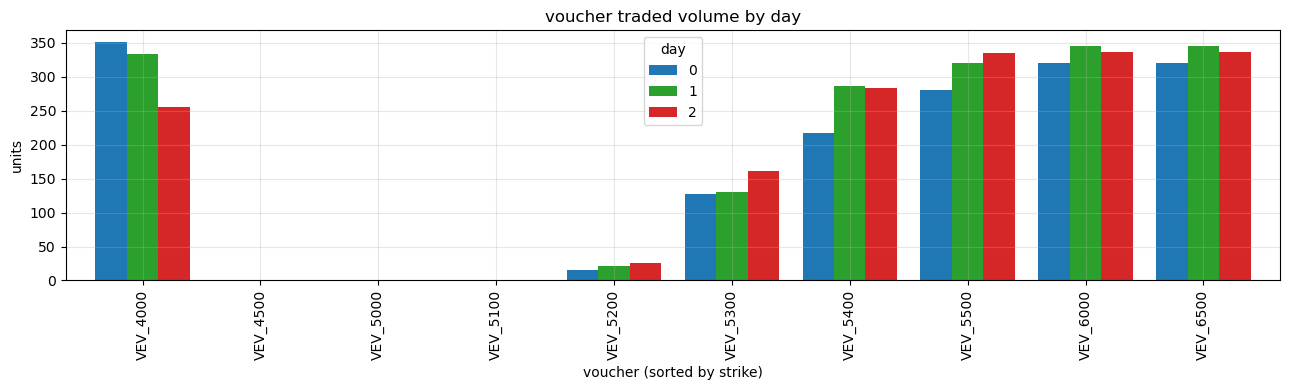

In [35]:
vvol = (
    trades[trades["symbol"].isin(VOUCHERS)]
    .groupby(["day", "symbol"])["quantity"].sum()
    .unstack(fill_value=0)
    .reindex(columns=sorted(VOUCHERS, key=lambda x: VOUCHER_K[x]))
)
print(vvol)

fig, ax = plt.subplots(figsize=(13, 4))
vvol.T.plot(kind="bar", ax=ax, width=0.8, color=["#1f77b4", "#2ca02c", "#d62728"][: len(vvol)])
ax.set_title("voucher traded volume by day")
ax.set_ylabel("units")
ax.set_xlabel("voucher (sorted by strike)")
plt.tight_layout()
plt.show()

## 3. Alpha discovery — the IV-scalping playbook

This is the 2024-winner playbook reproduced on this year's chain. The trick is:

1. **Invert Black-Scholes** at every (voucher, t) snapshot to get implied vol `v_t(K)`.
2. Plot `v_t` against **moneyness** `m_t = ln(S/K)/√T`. A clean parabola appears — the **vol smile**. Fit it once across the whole panel: `v̂(m) = a + b·m + c·m²`.
3. **Detrend.** `v_t − v̂(m_t)` is the IV deviation that's *not* explained by where the strike is. This should mean-revert.
4. **Translate to price.** Use `v̂(m_t)` as a "fair" IV → BS theoretical price → compare to market mid. The **price residual** is what we actually trade. Mean reversion is much cleaner here than in IV space.
5. **Validate.** 1-lag autocorrelation of the price residual changes should be **negative** — that's the statistical signature of an exploitable scalp.
6. **Underlying mean reversion.** Same autocorrelation test on VEV log returns vs random series — last year's secondary trade.

Everything below is calibrated on this year's `VEV_*` chain. Treat the strike-shape and which voucher is the strongest scalp as **empirical findings to validate**, not transferred conclusions.

### 3.1 Implied vol inversion

Per the wiki: historical day 0 starts at **TTE = 8 days**, decaying by 1 per day. Live Round 3 starts at TTE = 5d (we don't see those ticks here, but the constant `DAYS_TO_EXPIRY_AT_START = 8` makes the historical fit consistent).

Two notable changes vs. the first pass:
- **Continuous decay** (each tick advances time by `1/1e6` of a day) instead of full-day floors. That stops `m_t = ln(S/K)/sqrt(T)` from blowing up at day boundaries.
- **Tick-discreteness filter**: when a voucher mid sits at <= 1.0 the IV inversion is meaningless, so we null those points out before fitting.


In [36]:
# Black-Scholes call + Newton inversion, vectorized.
from scipy.stats import norm as _norm

# Wiki: historical day 0 starts at TTE=8d, decreasing by 1 each day.
DAYS_TO_EXPIRY_AT_START = 8
DAYS_PER_YEAR = 250
TICKS_PER_DAY = 1_000_000

def tte_years_from_t(t_arr):
    # Continuous decay: each tick advances time by 1/TICKS_PER_DAY of a day.
    days_elapsed = (t_arr - t_arr.min()) / TICKS_PER_DAY
    days_left = np.maximum(DAYS_TO_EXPIRY_AT_START - days_elapsed, 1e-6)
    return days_left / DAYS_PER_YEAR

def bs_call(S, K, T, sigma):
    S, K, T, sigma = [np.asarray(x, dtype=float) for x in (S, K, T, sigma)]
    sqrtT = np.sqrt(np.maximum(T, 1e-12))
    d1 = (np.log(np.maximum(S, 1e-12) / np.maximum(K, 1e-12)) + 0.5 * sigma * sigma * T) / np.maximum(sigma * sqrtT, 1e-12)
    d2 = d1 - sigma * sqrtT
    return S * _norm.cdf(d1) - K * _norm.cdf(d2)

def bs_vega(S, K, T, sigma):
    S, K, T, sigma = [np.asarray(x, dtype=float) for x in (S, K, T, sigma)]
    sqrtT = np.sqrt(np.maximum(T, 1e-12))
    d1 = (np.log(np.maximum(S, 1e-12) / np.maximum(K, 1e-12)) + 0.5 * sigma * sigma * T) / np.maximum(sigma * sqrtT, 1e-12)
    return S * _norm.pdf(d1) * sqrtT

def implied_vol(price, S, K, T, n_iter=40, tol=1e-6):
    sigma = np.full_like(np.asarray(price, dtype=float), 0.20)
    for _ in range(n_iter):
        diff = bs_call(S, K, T, sigma) - price
        v = bs_vega(S, K, T, sigma)
        step = np.where(v > 1e-10, diff / v, 0.0)
        sigma = np.clip(sigma - step, 1e-4, 5.0)
        if np.nanmax(np.abs(step)) < tol:
            break
    intrinsic = np.maximum(S - K, 0.0)
    bad = (price < intrinsic - 1e-9) | (~np.isfinite(price))
    sigma = np.where(bad, np.nan, sigma)
    return sigma

# Downsample so the whole notebook stays fast.
IV_STRIDE = 10
sub_idx = mids.index[::IV_STRIDE]
S_arr = mids[UNDERLYING].reindex(sub_idx).to_numpy()
T_arr = tte_years_from_t(sub_idx.to_numpy())

# Tick-discreteness filter.
TICK_FLOOR = 1.0

iv = pd.DataFrame(index=sub_idx, columns=VOUCHERS, dtype=float)
for v in VOUCHERS:
    K = VOUCHER_K[v]
    p = mids[v].reindex(sub_idx).to_numpy()
    sigma = implied_vol(p, S_arr, np.full_like(S_arr, K), T_arr)
    sigma = np.where(p < TICK_FLOOR, np.nan, sigma)
    iv[v] = sigma

print(f"TTE range (years): {T_arr.min():.4f} -> {T_arr.max():.4f}")
print(f"TTE range (days):  {T_arr.min()*DAYS_PER_YEAR:.2f} -> {T_arr.max()*DAYS_PER_YEAR:.2f}")
print("\nIV NaN counts per voucher (after tick-floor filter):")
print(iv.isna().sum())


/var/folders/mv/9j40839937z905spkz_pzj7c0000gn/T/ipykernel_77792/4290583609.py:33: RuntimeWarning: divide by zero encountered in divide
  step = np.where(v > 1e-10, diff / v, 0.0)


TTE range (years): 0.0200 -> 0.0320
TTE range (days):  5.00 -> 8.00

IV NaN counts per voucher (after tick-floor filter):
VEV_4000     309
VEV_4500     909
VEV_5000       0
VEV_5100       0
VEV_5200       0
VEV_5300       0
VEV_5400       0
VEV_5500       0
VEV_6000    3000
VEV_6500    3000
dtype: int64


### 3.2 Vol smile + parabolic fit

This is the headline plot from the writeup (Fig 6a). Every (voucher, t) point on one scatter, x = `m_t = ln(S/K)/√T`, y = `IV_t`. If the chain is internally consistent, all 10 strikes collapse onto one parabola. The fitted curve is `v̂(m)`.

global fit:  v_hat(m) = 0.2014 + 0.0196*m + -0.0097*m^2
ATM    fit:  v_hat(m) = 0.1982 + -0.0027*m + 0.0338*m^2  (strikes [5000, 5100, 5200, 5300, 5400, 5500])


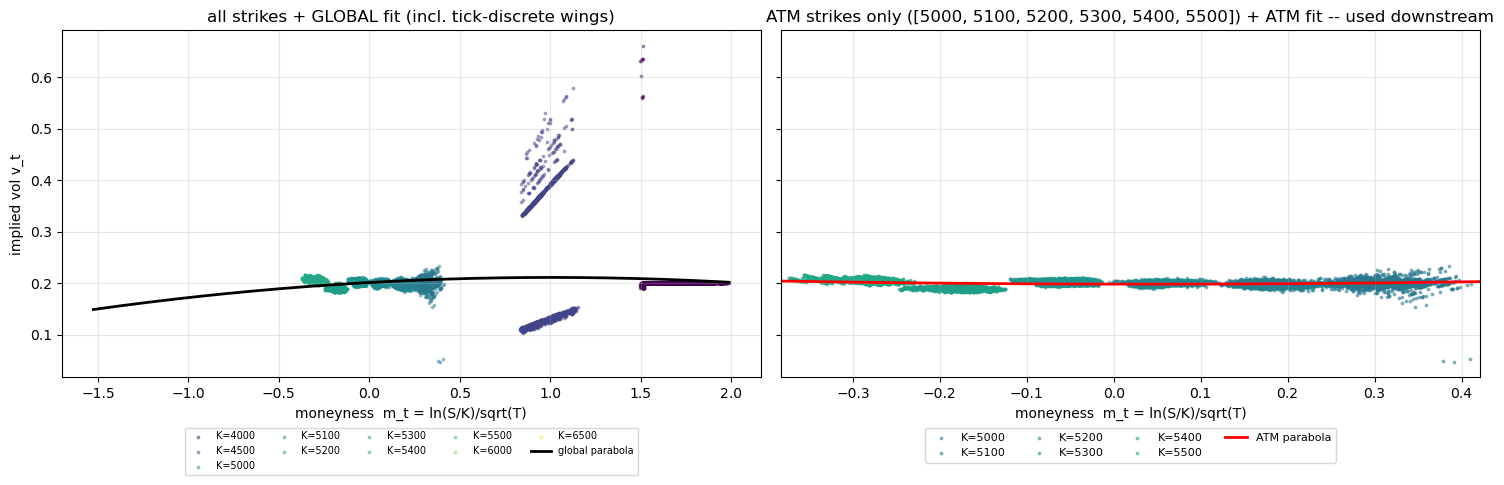

In [37]:
K_arr = np.array([VOUCHER_K[v] for v in VOUCHERS], dtype=float)
S_full = S_arr[:, None]
T_full = T_arr[:, None]
m_mat = np.log(S_full / K_arr[None, :]) / np.sqrt(np.maximum(T_full, 1e-12))
iv_mat = iv.to_numpy()

# Strikes we'll actually trade. Deep wings are tick-discrete on this chain; fitting on them just
# bends the parabola toward noise.
ATM_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]
ATM_VOUCHERS = [v for v in VOUCHERS if VOUCHER_K[v] in ATM_STRIKES]
ATM_COL_IDX = [VOUCHERS.index(v) for v in ATM_VOUCHERS]

def fit_smile(m_subset, v_subset):
    mask = np.isfinite(m_subset) & np.isfinite(v_subset) & (v_subset > 0.01) & (v_subset < 1.5)
    return np.polyfit(m_subset[mask], v_subset[mask], 2)

# Global fit (all 10 strikes) -- mostly for reference.
coef_global = fit_smile(m_mat.ravel(), iv_mat.ravel())
# ATM-only fit -- this is what we trade against.
coef_atm = fit_smile(m_mat[:, ATM_COL_IDX].ravel(), iv_mat[:, ATM_COL_IDX].ravel())

print(f"global fit:  v_hat(m) = {coef_global[2]:.4f} + {coef_global[1]:.4f}*m + {coef_global[0]:.4f}*m^2")
print(f"ATM    fit:  v_hat(m) = {coef_atm[2]:.4f} + {coef_atm[1]:.4f}*m + {coef_atm[0]:.4f}*m^2  (strikes {ATM_STRIKES})")

# This is the fit we use for residuals downstream.
coef = coef_atm

m_grid = np.linspace(np.nanmin(m_mat), np.nanmax(m_mat), 400)
v_global = np.polyval(coef_global, m_grid)
v_atm    = np.polyval(coef_atm,    m_grid)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Left: all strikes scatter + global fit.
ax = axes[0]
for v in sorted(VOUCHERS, key=lambda x: VOUCHER_K[x]):
    jj = VOUCHERS.index(v)
    ax.scatter(m_mat[:, jj], iv_mat[:, jj], s=3, alpha=0.4, color=VCOL[v], label=f"K={VOUCHER_K[v]}")
ax.plot(m_grid, v_global, color="black", lw=2, label="global parabola")
ax.set_xlabel("moneyness  m_t = ln(S/K)/sqrt(T)")
ax.set_ylabel("implied vol v_t")
ax.set_title("all strikes + GLOBAL fit (incl. tick-discrete wings)")
ax.legend(ncol=5, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.13))

# Right: ATM-only scatter + ATM fit.
ax = axes[1]
for v in ATM_VOUCHERS:
    jj = VOUCHERS.index(v)
    ax.scatter(m_mat[:, jj], iv_mat[:, jj], s=3, alpha=0.5, color=VCOL[v], label=f"K={VOUCHER_K[v]}")
ax.plot(m_grid, v_atm, color="red", lw=2, label="ATM parabola")
ax.set_xlabel("moneyness  m_t = ln(S/K)/sqrt(T)")
ax.set_title(f"ATM strikes only ({ATM_STRIKES}) + ATM fit -- used downstream")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.13))

# Trim to the ATM range for visibility on the right panel.
atm_m = m_mat[:, ATM_COL_IDX]
ax.set_xlim(np.nanmin(atm_m) - 0.01, np.nanmax(atm_m) + 0.01)

plt.tight_layout()
plt.show()


### 3.3 IV deviations over time -- `v_t - v_hat(m_t)`

Per-voucher residual after subtracting the **ATM** fitted parabola (`coef`). This is what we'll trade against. We still plot residuals for all 10 strikes for diagnosis -- if a deep wing has a giant residual that just means the ATM fit doesn't extrapolate there, not that there's alpha to harvest.


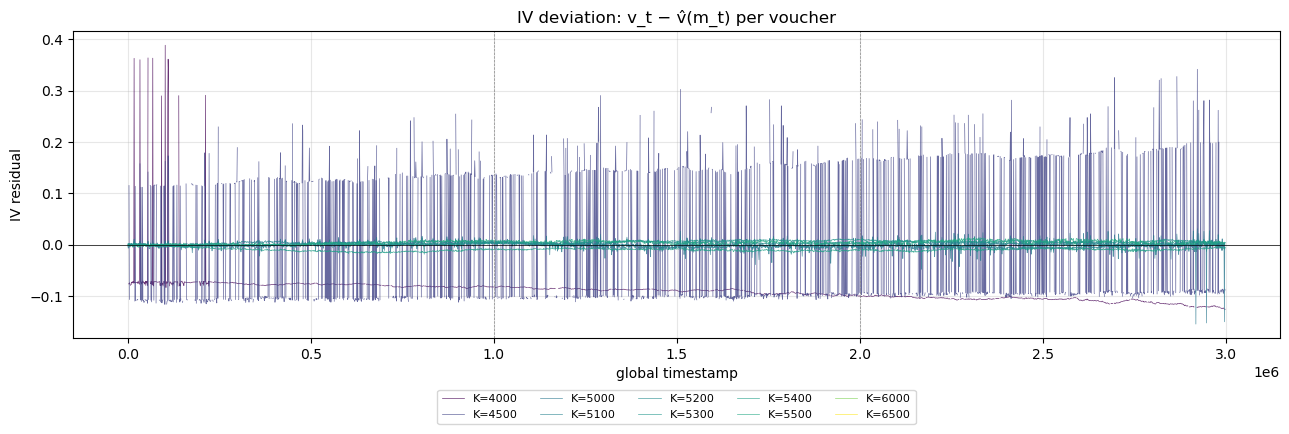

IV-residual std (bigger = thicker scalpable band):
VEV_4500    0.1295
VEV_4000    0.0305
VEV_5000    0.0077
VEV_5100    0.0043
VEV_5300    0.0037
VEV_5500    0.0033
VEV_5400    0.0030
VEV_5200    0.0029
VEV_6000       NaN
VEV_6500       NaN
dtype: float64


In [38]:
v_hat_mat = np.polyval(coef, m_mat)
iv_resid = iv_mat - v_hat_mat   # (T, 10)
iv_resid_df = pd.DataFrame(iv_resid, index=sub_idx, columns=VOUCHERS)

fig, ax = plt.subplots(figsize=(13, 4.5))
for v in sorted(VOUCHERS, key=lambda x: VOUCHER_K[x]):
    ax.plot(iv_resid_df.index, iv_resid_df[v], color=VCOL[v], lw=0.5, alpha=0.8, label=f"K={VOUCHER_K[v]}")
for tb in day_bounds:
    ax.axvline(tb, color="#888", lw=0.5, ls="--")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("IV deviation: v_t − v̂(m_t) per voucher")
ax.set_xlabel("global timestamp")
ax.set_ylabel("IV residual")
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

print("IV-residual std (bigger = thicker scalpable band):")
print(iv_resid_df.std().sort_values(ascending=False).round(4))

### 3.4 Price-space residuals — the actual trade signal

Fig 6c / 7a. Convert `v̂(m_t)` back to a BS theoretical price `C_theo(S_t, K, T_t, v̂(m_t))` and subtract from market mid. Mean reversion is **much** cleaner in price than in IV — that's why this is the version we trade.

Print at the bottom: per-voucher residual std (in price units) and the **1-lag autocorrelation of `Δ(residual)`** — the winner's validation. Strongly negative ACF(1) ≈ exploitable scalp.

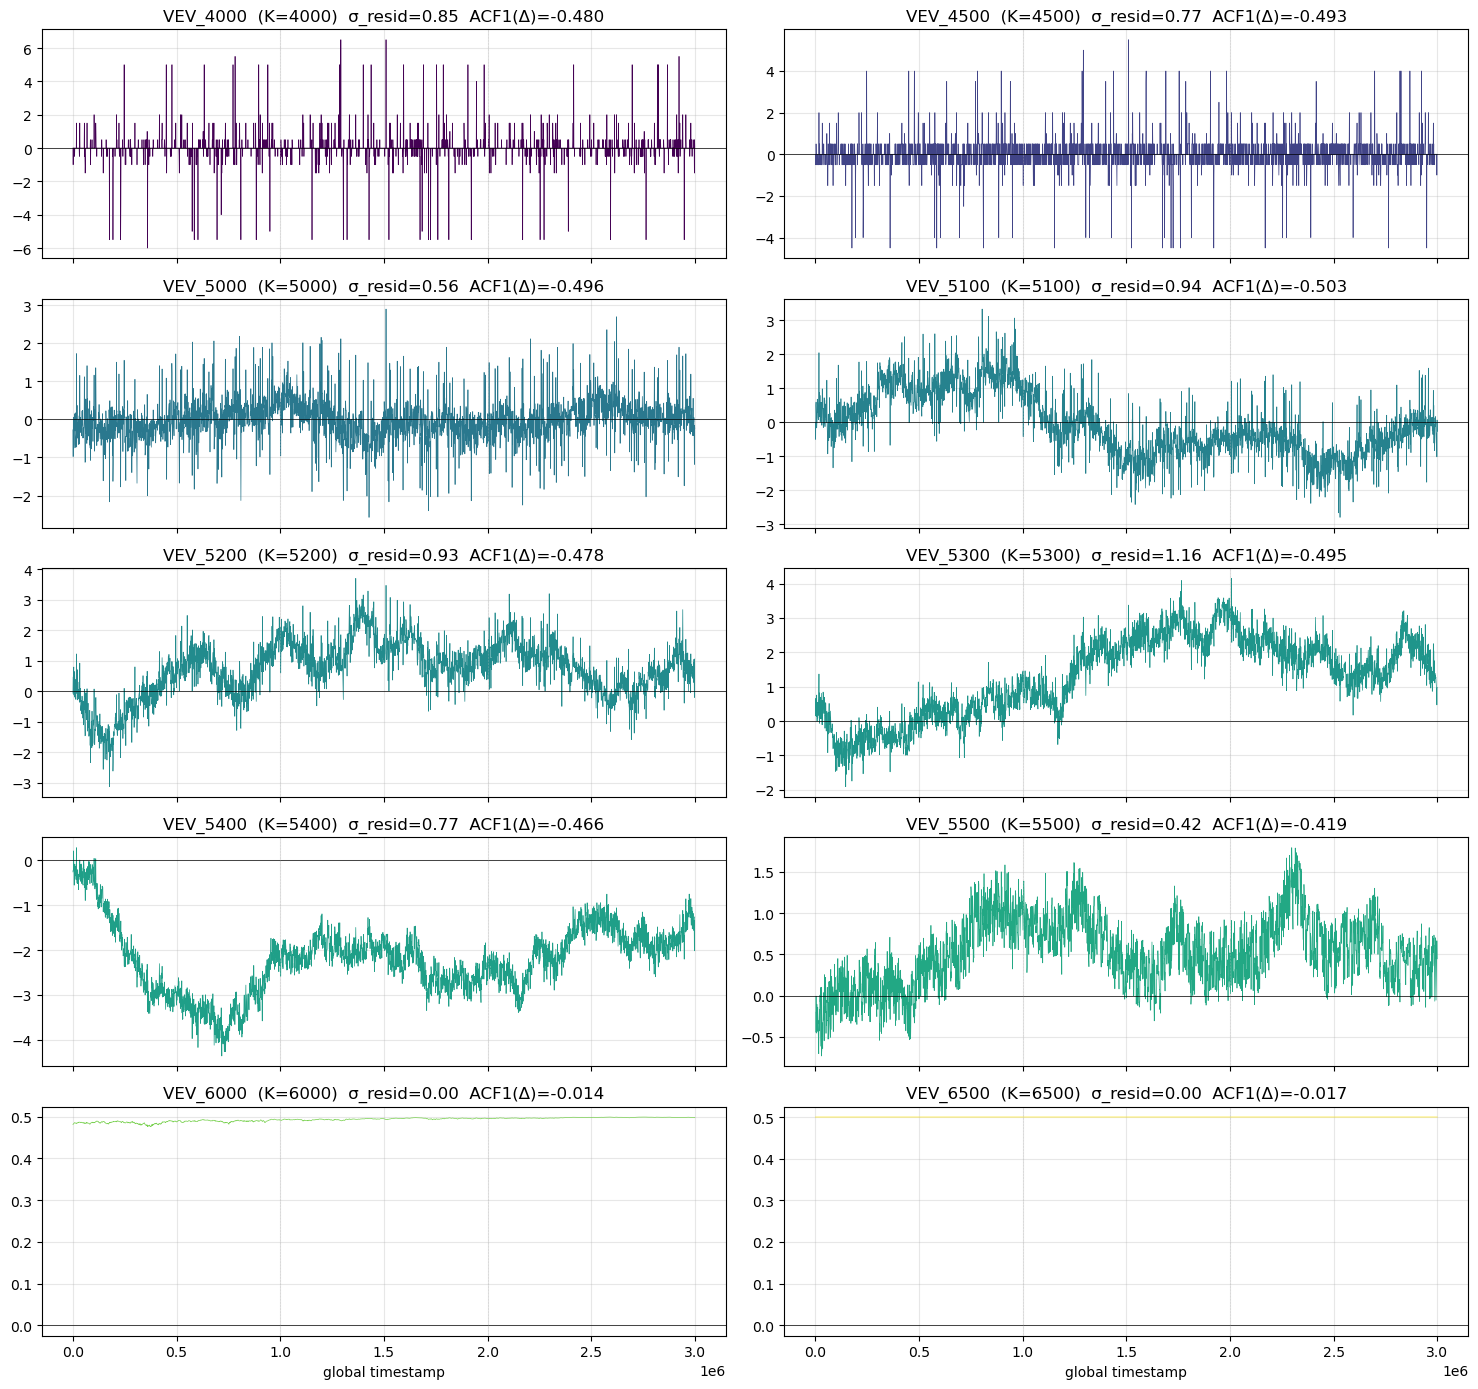


1-lag ACF of price-residual changes (more negative = stronger mean reversion → better scalp):
VEV_4000   -0.480
VEV_4500   -0.493
VEV_5000   -0.496
VEV_5100   -0.503
VEV_5200   -0.478
VEV_5300   -0.495
VEV_5400   -0.466
VEV_5500   -0.419
VEV_6000   -0.014
VEV_6500   -0.017
dtype: float64


In [39]:
bs_theo = bs_call(S_full, K_arr[None, :], T_full, v_hat_mat)   # (T, 10)
mids_sub = mids.reindex(sub_idx)[VOUCHERS].to_numpy()
price_resid = mids_sub - bs_theo
price_resid_df = pd.DataFrame(price_resid, index=sub_idx, columns=VOUCHERS)

fig, axes = plt.subplots(5, 2, figsize=(15, 14), sharex=True)
acf1 = {}
for i, v in enumerate(sorted(VOUCHERS, key=lambda x: VOUCHER_K[x])):
    ax = axes[i // 2, i % 2]
    s = price_resid_df[v]
    ax.plot(s.index, s.values, color=VCOL[v], lw=0.5)
    ax.axhline(0, color="black", lw=0.5)
    for tb in day_bounds:
        ax.axvline(tb, color="#bbb", lw=0.4, ls=":")
    ds = s.diff().dropna()
    if len(ds) > 50:
        a1 = ds.autocorr(lag=1)
    else:
        a1 = np.nan
    acf1[v] = a1
    ax.set_title(f"{v}  (K={VOUCHER_K[v]})  σ_resid={s.std():.2f}  ACF1(Δ)={a1:+.3f}")
axes[-1, 0].set_xlabel("global timestamp")
axes[-1, 1].set_xlabel("global timestamp")
plt.tight_layout()
plt.show()

acf_series = pd.Series(acf1).reindex(sorted(VOUCHERS, key=lambda x: VOUCHER_K[x]))
print("\n1-lag ACF of price-residual changes (more negative = stronger mean reversion → better scalp):")
print(acf_series.round(3))

### 3.5 ACF bar — pick the strikes to scalp

A simple ranked view of section 3.4's last column. Strongly-negative bars are the candidates. The 2024 winners started with the 10000 strike (closest to ATM at the time) and expanded as the chain shifted — same logic should apply here: prioritize strikes near current `S` *and* with a clearly negative ACF1.

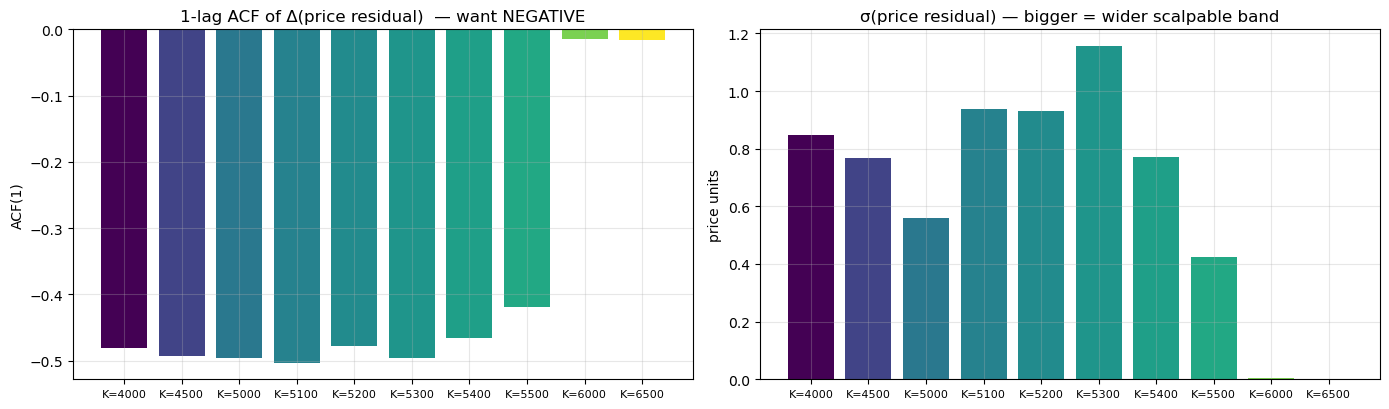

In [40]:
order = sorted(VOUCHERS, key=lambda x: VOUCHER_K[x])
acf_series = acf_series.reindex(order)
sigma_resid = price_resid_df.std().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(range(len(order)), acf_series.values, color=[VCOL[v] for v in order])
axes[0].axhline(0, color="black", lw=0.6)
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels([f"K={VOUCHER_K[v]}" for v in order], rotation=0, fontsize=8)
axes[0].set_title("1-lag ACF of Δ(price residual)  — want NEGATIVE")
axes[0].set_ylabel("ACF(1)")

axes[1].bar(range(len(order)), sigma_resid.values, color=[VCOL[v] for v in order])
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels([f"K={VOUCHER_K[v]}" for v in order], rotation=0, fontsize=8)
axes[1].set_title("σ(price residual) — bigger = wider scalpable band")
axes[1].set_ylabel("price units")

plt.tight_layout()
plt.show()

### 3.6 Underlying mean-reversion check (Fig 8 reproduction)

Last year's secondary trade. Rolling autocorrelation of VEV log returns, compared against autocorrelations of pure white-noise series of the same length. If the VEV line falls below the random-series envelope (especially negative), there's a mean-reversion signal independent of the options chain.

Caveat: only 3 days of data, and last year's writeup explicitly warns this signal is volatile. Treat as a hedge, not a primary trade.

In [ ]:
# Rolling 1-lag autocorr on VEV log returns vs N random Gaussian series.
# Vectorized: for each window length w, mean rolling ACF(1) ~= corr(x[w:], x[w-1:-1]) computed
# blockwise. We use a fast closed-form: mean of the rolling-window ACF(1) values approximates
# the global lag-1 autocorrelation when w is large, but to keep the original semantics we
# compute it via numba-free cumulative sums.

vev_logret = np.log(mids[UNDERLYING].where(mids[UNDERLYING] > 0)).diff().dropna().values
n = len(vev_logret)
print("VEV log-return sample size:", n)

def rolling_acf1_mean(x, win):
    # Mean of rolling lag-1 autocorrelation across all windows of length `win`.
    # Computed via stride tricks for speed.
    if len(x) < win + 1:
        return np.nan
    from numpy.lib.stride_tricks import sliding_window_view
    W = sliding_window_view(x, win)            # (n-win+1, win)
    a = W[:, :-1]
    b = W[:, 1:]
    am = a.mean(axis=1, keepdims=True)
    bm = b.mean(axis=1, keepdims=True)
    num = ((a - am) * (b - bm)).sum(axis=1)
    den = np.sqrt(((a - am) ** 2).sum(axis=1) * ((b - bm) ** 2).sum(axis=1))
    den = np.where(den == 0, np.nan, den)
    return np.nanmean(num / den)

WINS = list(range(5, 100, 2))
vev_curve = [rolling_acf1_mean(vev_logret, w) for w in WINS]

rng = np.random.default_rng(0)
N_RAND = 100
rand_curves = np.zeros((N_RAND, len(WINS)))
for i in range(N_RAND):
    x = rng.standard_normal(n)
    for j, w in enumerate(WINS):
        rand_curves[i, j] = rolling_acf1_mean(x, w)

fig, ax = plt.subplots(figsize=(13, 4.5))
for i in range(N_RAND):
    ax.plot(WINS, rand_curves[i], color="black", lw=0.3, alpha=0.3)
ax.plot(WINS, vev_curve, color="red", lw=2, label="VELVETFRUIT_EXTRACT")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("rolling window (ticks)")
ax.set_ylabel("mean rolling ACF(1)")
ax.set_title("VEV mean-reversion test -- VEV vs 100 random Gaussian series")
ax.legend()
plt.tight_layout()
plt.show()

print(f"VEV ACF1 at win=15: {vev_curve[5]:+.4f}   |   random envelope at win=15: [{rand_curves[:,5].min():+.4f}, {rand_curves[:,5].max():+.4f}]")
print(f"VEV ACF1 at win=49: {vev_curve[22]:+.4f}   |   random envelope at win=49: [{rand_curves[:,22].min():+.4f}, {rand_curves[:,22].max():+.4f}]")


VEV log-return sample size: 29999


### 3.7 Alpha shortlist -- updated

After re-fitting on ATM-only with corrected TTE:

1. **IV scalping on K=5200, 5300** -- biggest sigma_resid, ACF1 still strongly negative. Primary trade.
2. **Expand to K=5100/5400** -- thinner band, but ACF1 is even more negative on K=5100. Secondary scalps.
3. **Adjacent-strike Z-score (3.8)** -- sanity-check layer. If a pair Z-score blows out, that's an extra entry signal independent of the smile fit.
4. **HYDROGEL_PACK EMA deviation (1.6)** -- separate trade, separate position limit, no interaction with the option chain.
5. **VEV mean-reversion (3.6)** -- only act if the red line is clearly outside the random envelope. Otherwise skip; don't force it.


### 3.8 Adjacent-strike IV pair Z-scores (second alpha layer)

Same idea as the residuals from 3.4, but cleaner because we don't need a smile fit at all: just diff the IVs of two adjacent strikes. The diff is mean-stationary (the smile shape between two close strikes barely moves), so a rolling Z-score of `IV(K_low) - IV(K_high)` is a tradable signal -- when it blows out, sell the rich leg / buy the cheap leg.

We restrict to ATM-only pairs because the wings have NaN IVs from the tick-floor filter.

In [ ]:
sorted_atm = sorted(ATM_VOUCHERS, key=lambda v: VOUCHER_K[v])
pairs = list(zip(sorted_atm[:-1], sorted_atm[1:]))

ROLL = 1000   # ~1000 IV-grid ticks = 10000 raw ticks
fig, axes = plt.subplots(len(pairs), 1, figsize=(13, 1.8 * len(pairs)), sharex=True)
acf1_pairs = {}
for ax, (vL, vR) in zip(axes, pairs):
    diff = iv[vL] - iv[vR]
    mu = diff.rolling(ROLL).mean()
    sd = diff.rolling(ROLL).std()
    z = (diff - mu) / sd
    a1 = z.diff().dropna().autocorr(lag=1)
    acf1_pairs[f"{vL}-{vR}"] = a1

    ax.plot(z.index, z.values, color="#444", lw=0.5)
    ax.axhline(0, color="black", lw=0.5)
    for k, ls in [(2, ":"), (3, "--")]:
        ax.axhline(+k, color="#d62728", lw=0.5, ls=ls)
        ax.axhline(-k, color="#d62728", lw=0.5, ls=ls)
    for tb in day_bounds:
        ax.axvline(tb, color="#bbb", lw=0.4, ls=":")
    ax.set_title(f"{vL} - {vR}   IV-diff Z-score (roll={ROLL})   ACF1(d.Z)={a1:+.3f}")
    ax.set_ylabel("Z")
    ax.set_ylim(-6, 6)
axes[-1].set_xlabel("global timestamp")
plt.tight_layout()
plt.show()

print("\nACF1(d.Z) per pair (more negative = stronger mean reversion):")
for k, v in sorted(acf1_pairs.items(), key=lambda kv: kv[1]):
    print(f"  {k:25s} {v:+.3f}")


## Notes for next pass

Once the basics here look sane, the natural follow-ups are:

- **Time value over time.** `mid − max(S − K, 0)` for ATM strikes — this is the only thing decaying as expiry approaches. Its slope ≈ theta.
- **Smile / IV surface.** Only meaningful once we trust the price-vs-strike snapshot from §2.2.
- **HYDROGEL_PACK** has nothing to do with the option chain. If §1 reveals any structure (mean-reversion, regime, etc.) it's a separate trade and lives elsewhere.